In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("IPL.csv")
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


**Bsic Information Like DataType & Column**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

Check the size of rows and columns of the dataset

In [5]:
df.shape

(74, 20)

In [6]:
print(f"Your rows are {df.shape[0]} and your columns are {df.shape[1]}")

Your rows are 74 and your columns are 20


Now lets see how many cloumns have null values in total.

In [7]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

1.Which team won the most matches ?

Text(0.5, 1.0, 'Most match win by Team')

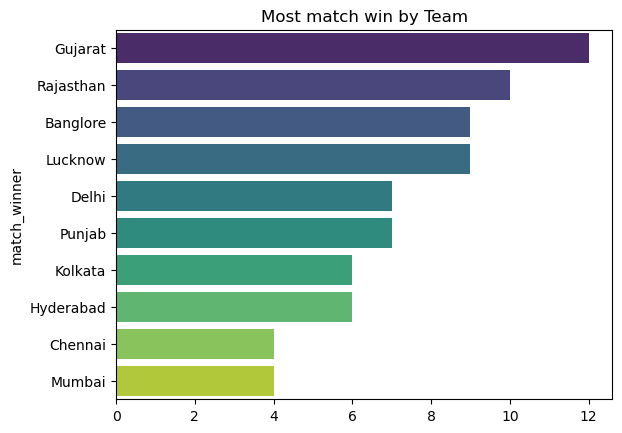

In [8]:
# df['match_winner'].value_counts()
match_wins = df['match_winner'].value_counts()
sns.barplot(y = match_wins.index, x = match_wins.values,palette = 'viridis')
plt.title("Most match win by Team")

2. Toss Decision Trends

Text(0.5, 1.0, 'Toss Decision Trends')

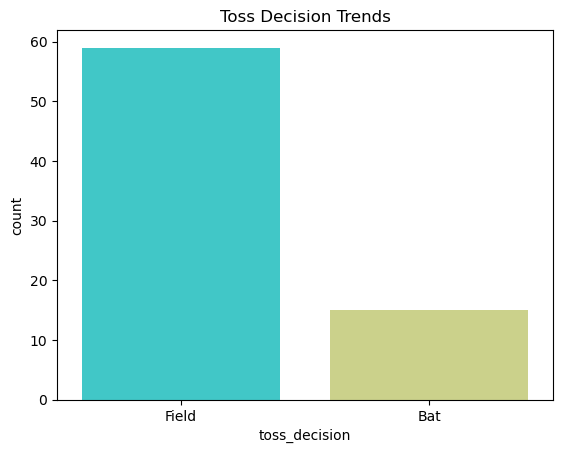

In [9]:
# df.head()
sns.countplot(x = df['toss_decision'], palette = 'rainbow')
plt.title("Toss Decision Trends")

3.Toss Winner vs Match Winner

In [10]:
# df[df['toss_winner'] == df['match_winner']].count()
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count *100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

4. How do teams win?(Runs vs Wickets)

Text(0.5, 1.0, 'Won By')

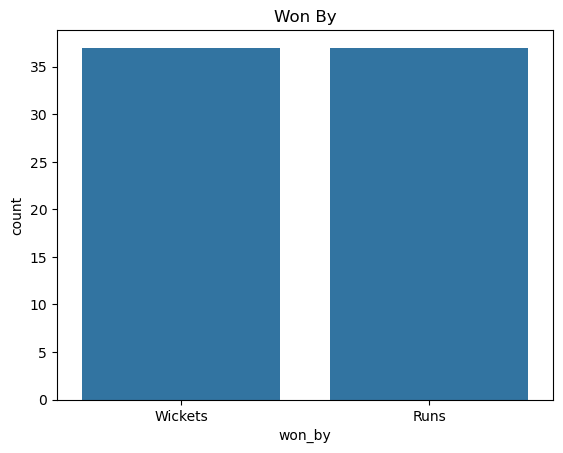

In [11]:
sns.countplot(x= df['won_by'])
plt.title("Won By")

** Key Player Performances**

1. Most "Player of the Match" Awards

Text(0.5, 1.0, 'Top 10 Playes with Man of the match')

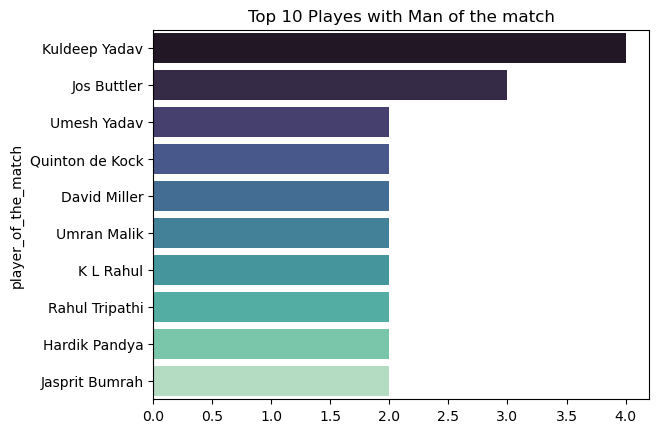

In [12]:
# df.head()
count = df['player_of_the_match'].value_counts().head(10)
# count.head(1)
sns.barplot(x = count.values, y = count.index, palette='mako')
plt.title("Top 10 Playes with Man of the match")

2. Top Scorers

In [18]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending = False).head(5)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
KL Rahul           351
Shubman Gill       288
Faf du Plessis     257
Name: highscore, dtype: int64

In [25]:
high_Scorer = df.groupby('top_scorer').agg(
    Total_Highscore = ('highscore', 'sum'),
    Match_as_Top_Scorer = ('top_scorer','count')
).sort_values(by='Total_Highscore', ascending = False)
high_Scorer.head(5)

,Total_Highscore,Match_as_Top_Scorer
top_scorer,,
Jos Buttler,651,7
Quinton de Kock,377,5
KL Rahul,351,4
Shubman Gill,288,4
Faf du Plessis,257,3


In [32]:
high_Scorer['Match_as_Top_Scorer'].sum()

np.int64(74)

In [30]:
# df.head()
df['match_id'].nunique()

74

<Axes: ylabel='top_scorer'>

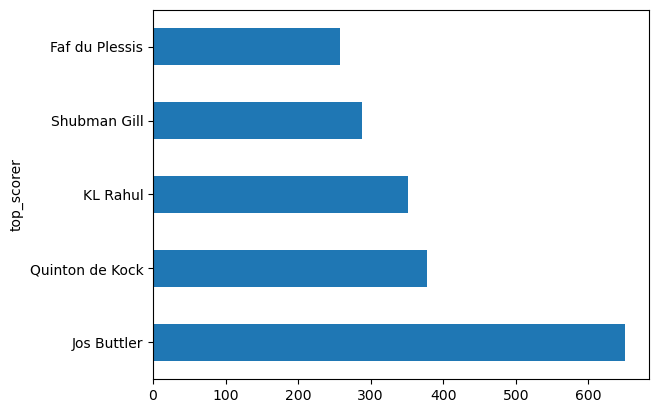

In [36]:
high.plot(kind = 'barh')

10 Best Bowling Figures

In [46]:
# df.head()
df['highest_wikets'] = df['best_bowling_figure'].apply(lambda x: x.split('--')[0])
df['highest_wikets'] = df['highest_wikets'].astype(int)
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wikets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3


In [42]:
top_bowlers = df.groupby('best_bowling')['highest_wikets'].sum().sort_values(ascending = False)
top_bowlers.head(10)

best_bowling
Yuzvendra Chahal     17
Kuldeep Yadav        11
Rashid Khan          11
Jasprit Bumrah       11
Avesh Khan           10
Josh Hazlewood       10
Kagiso Rabada        10
Wanindu Hasaranga     9
Umran Malik           9
T Natarajan           8
Name: highest_wikets, dtype: int64

Text(0.5, 1.0, 'Total Wikets by Best Bowling Figure')

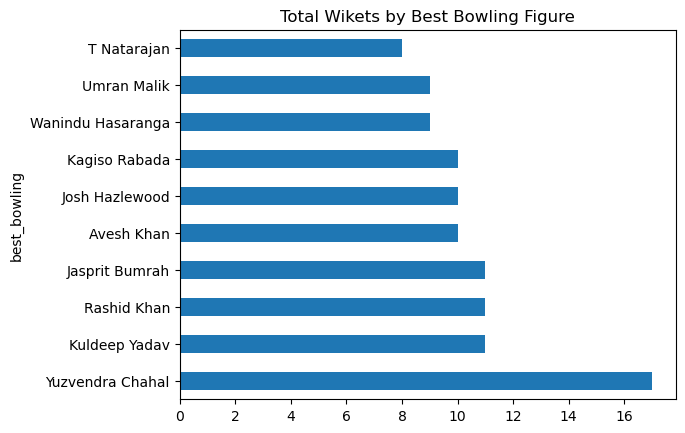

In [48]:
top_bowlers.head(10).plot(kind = 'barh')
plt.title("Total Wikets by Best Bowling Figure")

**Venue Analysis**

Most matches Played by venue

In [51]:
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

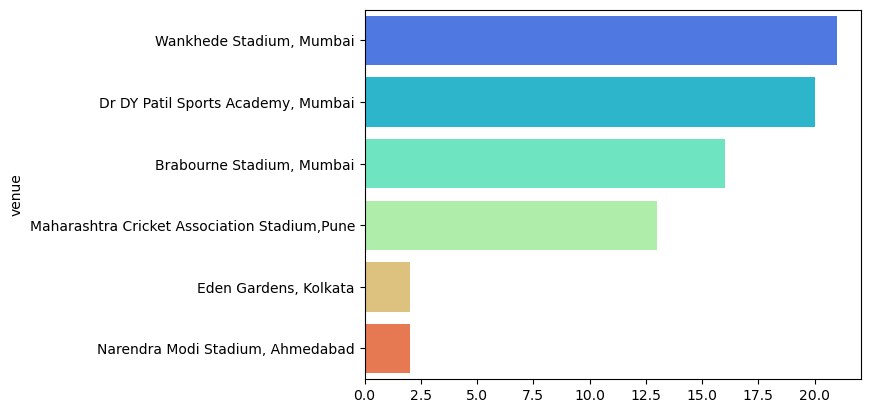

In [54]:
sns.barplot(y=venue_count.index, x= venue_count.values, palette='rainbow')

**Custom Question**

Who won the highest margin by runs ?

In [59]:
df[df['won_by'] == "Runs"].sort_values(by = 'margin',ascending=False).head(1)[['match_winner', 'margin']]

,match_winner,margin
54,Chennai,91


Which player had the highest individual score ?

In [61]:
df[df['highscore'] == df['highscore'].max()][['top_scorer', 'highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


In [62]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure', 'highest_wikets'],
      dtype='object')

Which bowler had the best bowling figures ?

In [64]:
df[df['highest_wikets'] == df['highest_wikets'].max()][['best_bowling', 'best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10


Highest Score By a team

In [73]:
team1_score = df[['team1', 'team2', 'first_ings_score']].rename(
    columns = {
        'team1': 'team',
        'team2': 'opponent',
        'first_ings_score': 'score'
    }
)
team2_score = df[['team2', 'team1', 'second_ings_score']].rename(
    columns = {
        'team2': 'team',
        'team1': 'opponent',
        'second_ings_score':'score'
    }
)

team_scores = pd.concat([team1_score, team2_score], ignore_index=True)
team_scores.loc[team_scores['score'].idxmax()]


team            Delhi
opponent    Rajasthan
score             222
Name: 33, dtype: object

Highest Successfull chase

In [69]:
chase = df[df['match_winner'] == df['team2']][
    ['team2', 'team1', 'second_ings_score']
].rename(columns={
    'team2':'team',
    'team1': 'opponent',
    'second_ings_score':'score'
})
chase.loc[chase['score'].idxmax()]


team        Lucknow
opponent    Chennai
score           211
Name: 6, dtype: object

Highest First Inning Score

In [71]:
run_wins = df[df['won_by'] == 'Runs']

In [72]:
run_wins.loc[
    run_wins['first_ings_score'].idxmax(),
    ['team1', 'team2', 'first_ings_score']
]

team1                   Delhi
team2               Rajasthan
first_ings_score          222
Name: 33, dtype: object

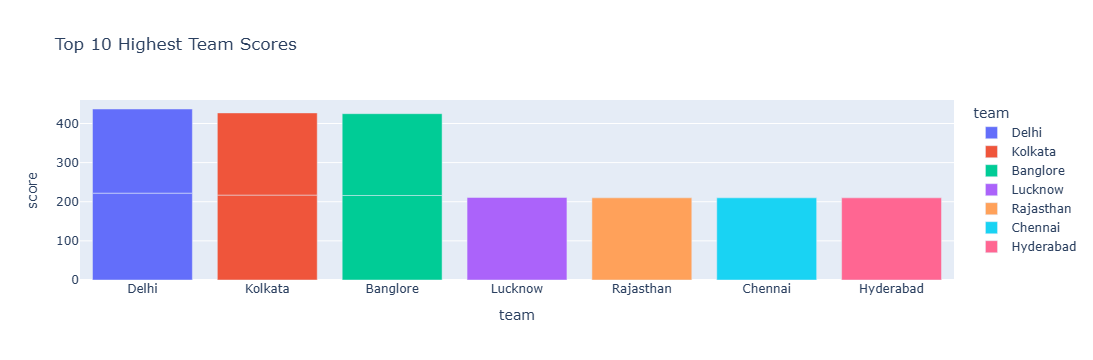

In [75]:
import plotly.express as px
top10 = team_scores.sort_values(by='score',ascending= False).head(10)
fig = px.bar(
    top10,
    x ='team',
    y = 'score',
    color = 'team',
    hover_data=['opponent'],
    title='Top 10 Highest Team Scores'
)
fig.show()